# PSE-823: Advanced Process Dynamics and Control
## Lecture 1 -- Control Fundamentals and the DCS Layer
### (Coughanowr & LeBlanc, Ch. 1; Cecil Smith, Intro and Sec. 1.1-1.2)

Date: __________

## How every lecture works

- Each idea is **introduced** as a physical question.
- It is **derived** on the board, one step per slide.
- Then **code repeats the derivation**, step for step.
- Then the code goes **further** than hand algebra can.
- In class you **read** the code and predict what it prints.

No laptops in class. Every code cell is projected and run by the
instructor. The class's job is code *interpretation*: say what a line
does and predict the output before it is run. Each code slide has an
explain slide above it and a line-by-line walkthrough in the speaker
notes (press S in the slides; visible as a normal cell in Colab).

## The course in one picture

- **Coughanowr & LeBlanc** -- the spine (about 80%): models,
  transfer functions, stability, frequency response, state space.
- **Cecil Smith** -- the industrial layer (about 20%): cascade,
  override, ratio, decoupling, and the course's only MPC source.
- Weeks 1-8: classical theory, then the **midterm**.
- Weeks 9-15: advanced strategies, identification, MPC.

## Agenda

**Part A** -- Feedback control of a hot water tank (Ch. 1, Ex. 1.1)

**Part B** -- Proportional and integral control; offset (Ch. 1)

**Part C** -- Apparent error and a first look at instability (Ch. 1)

**Part D** -- Narrow the variance, shift the target; DCS blocks
(Cecil Smith, Intro and Sec. 1.1-1.2)

### Setup (run once)

- Every library this lecture uses, imported once
- `plt.rcParams` makes plot text readable on the projector

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
plt.rcParams.update({"font.size": 15})

## Part A
### Feedback Control of a Hot Water Tank

(Coughanowr & LeBlanc, Ch. 1, Example 1.1)
<!-- source: coughanowr-ch1 -->

### Introduce -- the home hot water heater (Ex. 1.1)

- **Controlled variable:** water temperature $T$; set point 130 F.
- **Manipulated variable:** fuel to the burner (valve open or shut).
- **Disturbances:** hot water drawn off and replaced by cold feed;
  heat lost to the surroundings.
- Thermocouple measures $T$; the thermostat is the **controller**.

![](https://haiderejaz6.github.io/ProcessControl/lectures/01-intro-fundamentals/images/fig1-4_hot_water_tank_a.jpeg)

Fig. 1-2 of the book. Name each element out loud: thermocouple =
measuring element, thermostat = controller, fuel valve = final control
element, tank = process. This vocabulary is used for all 15 weeks.

### Introduce -- the block diagram (Fig. 1-1, Fig. 1-3)

Information flows around a **loop**: measure, compare, act.

![](https://haiderejaz6.github.io/ProcessControl/lectures/01-intro-fundamentals/images/fig1-3_generalized_block_diagram.jpeg)

### Introduce -- a model to experiment with

To simulate the tank we need its dynamics. Lecture 2 derives them from
an energy balance; for now we take the result:

$$\tau\,\frac{dT}{dt} = (T_i - T) + K\,q$$

$T_i$: cold feed temperature, $q$: burner on-fraction (0 to 1).
Illustrative values: $\tau = 30$ min, $K = 90$ F, $T_i = 60$ F.

The book gives only the 130 F set point; tau, K and Ti are illustrative
numbers for a domestic heater, chosen so that full burner holds
60 + 90 = 150 F. Lecture 2 derives this equation (heated tank energy
balance), so this is a forward reference, not a new scenario.

### Derive 1/2 -- the error and the on/off law

The thermostat computes the error (Ch. 1):

$$e = T_{\text{set}} - T_{\text{measured}}$$

On/off law: if $e > 0$ open the fuel valve ($q=1$); if $e \le 0$
close it ($q=0$). No values in between.

### Derive 2/2 -- what burner fraction does 130 F need?

At steady state $dT/dt = 0$, so $0 = (T_i - T) + Kq$:

$$q_s = \frac{T - T_i}{K} = \frac{130 - 60}{90} = 0.778$$

On/off cannot output 0.778. It must **cycle**: on about 78% of the
time, off about 22%.

### Code 1/3 -- the tank model as a function

- A Python `def` turns the model equation into reusable code
- It returns $dT/dt$: the right-hand side divided by $\tau$
- Mirrors the model slide, symbol for symbol

In [2]:
tau, K = 30.0, 90.0                 # min, F

def dTdt(T, Ti, q):
    # tau dT/dt = (Ti - T) + K q
    return ((Ti - T) + K * q) / tau

print(dTdt(130.0, 60.0, 0.778))     # ~0 at steady state
print(dTdt(130.0, 60.0, 1.0))       # burner on: heating

0.000666666666666534
0.6666666666666666


**Code walkthrough.** Line 1 stores the two model parameters. `def dTdt(T, Ti, q):` defines
a function with three inputs; the comment repeats the model so the code
can be read against the slide. The body is the model solved for dT/dt.
The first print evaluates it at 130 F with q = 0.778: the result is
about 0 (0.0007 F/min, left over from rounding 0.7778 to 0.778),
which confirms Derive 2/2.
The second print, burner fully on, gives (60 - 130 + 90)/30 = 0.667
F/min: the water heats at two thirds of a degree per minute. Common
mistake: forgetting to divide by tau and reading the result as a rate
thirty times too large.

### Code 2/3 -- the thermostat as a function

- The on/off law of Derive 1/2, in four lines
- `if ... else` is the decision; there is no middle value

In [3]:
def thermostat(T_meas, T_set=130.0):
    e = T_set - T_meas          # error (Ch. 1)
    return 1.0 if e > 0 else 0.0

for T in [128.0, 130.0, 131.5]:
    print(T, "->", thermostat(T))

128.0 -> 1.0
130.0 -> 0.0
131.5 -> 0.0


**Code walkthrough.** `T_set=130.0` is a default argument: the set point unless another is
passed. Line 2 is the book's error definition. Line 3 is a one-line if/
else: 1.0 (burner on) when the error is positive, 0.0 otherwise. The
loop prints three cases: 128 -> 1.0 (too cold, burn), 130 -> 0.0
(error exactly zero counts as "off", as in the book), 131.5 -> 0.0.
Ask the class to predict the middle line before running; most say 1.0.

### Code 3/3 -- closing the loop, one sample at a time

- Every `dt` minutes: **measure**, **decide**, **update** the tank
- The update is Euler's method: $T \leftarrow T + \Delta t\,dT/dt$
- Start cold (100 F) and run for 90 min

In [4]:
dt, T = 0.1, 100.0               # min, F (cold start)
log_T, log_q = [], []
for k in range(int(90 / dt)):
    q = thermostat(T)            # measure and decide
    T = T + dt * dTdt(T, 60.0, q)  # tank responds
    log_T.append(T)
    log_q.append(q)
log_T, log_q = np.array(log_T), np.array(log_q)
i = np.argmax(log_T >= 130)      # first time at set point
print(f"reaches 130 F at {i*dt:.1f} min")
print(f"burner on {log_q[i:].mean():.1%} of the time after")

reaches 130 F at 27.4 min
burner on 77.6% of the time after


**Code walkthrough.** This cell *is* the block diagram of Fig. 1-1, written as a loop. Line 1
sets the sampling interval (0.1 min) and the cold start. Each pass of
the `for` loop calls the controller (thermostat) and then the process
(dTdt), and stores the result. `np.argmax(log_T >= 130)` finds the
first index where the condition is True. Expected output: the set point
is reached at about 27.4 min (from T = 150 - 50 e^(-t/30), the heat-up
takes 30 ln 2.5 = 27.5 min), and afterwards the burner is on 77.6% of
the time -- the 0.778 of Derive 2/2, delivered as a duty cycle.

### Plot -- on/off control in action

- Top: temperature. Bottom: burner state
- `sharex=True` lines the two time axes up

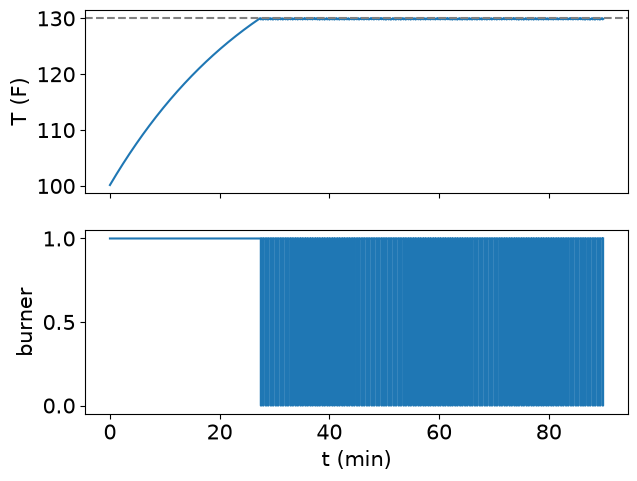

In [5]:
t = np.arange(len(log_T)) * dt
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5.25),
                               sharex=True)
ax1.plot(t, log_T)
ax1.axhline(130, ls="--", c="gray")
ax1.set_ylabel("T (F)")
ax2.step(t, log_q, where="post")
ax2.set(xlabel="t (min)", ylabel="burner")
plt.show()

**Code walkthrough.** `np.arange(len(log_T)) * dt` rebuilds the time axis. `plt.subplots(2, 1,
...)` makes two stacked panels sharing the x axis. `step` draws the
burner signal as a staircase, which is what an on/off signal is. Read
the plot: a smooth heat-up curve, then the temperature pinned at 130 F
while the burner chatters on and off every few samples. Real
thermostats add a deadband (switch on at 128, off at 132) so the burner
cycles minutes apart, not seconds; that is a design choice, not physics.

### Your Turn (8 min)

1. By hand: in winter the cold feed drops to $T_i = 50$ F.
   What fraction of the time must the burner now be on?
2. Read the code: what does this print?

```python
for T in [131.0, 129.9]:
    print(thermostat(T, T_set=132.0))
```

(1) q_s = (130 - 50)/90 = 0.889: on about 89% of the time.
(2) Prints 1.0 then 1.0: with a set point of 132 F both readings are
below the set point, so both errors are positive. The trap is reading
the default 130 F instead of the T_set=132.0 that is passed in.

### Check -- cold-call

The thermocouple wire breaks and the thermostat stops receiving $T$.

Is this still a control system? Which word in Ch. 1 describes it?

It becomes **open loop** (manual mode): the measurement is disconnected,
so the controller output no longer depends on T. Someone has to set the
burner by hand. Closed loop = automatic; open loop = manual (Ch. 1).

## Part B
### Proportional and Integral Control; Offset

(Coughanowr & LeBlanc, Ch. 1, Types of Controllers)
<!-- source: coughanowr-ch1 -->

### Introduce -- act in proportion to the error

- **Proportional (P):** change the heat input in proportion to $e$:
  $$q = q_s + K_c\,e$$
- $K_c$ is the **controller gain**, our design choice.
- Book's claim: larger $K_c$, smaller steady error -- but **never zero**.
- Test case: winter arrives, $T_i$ drops from 60 to 50 F.

### Derive 1/3 -- steady state with the P law

Set $dT/dt = 0$ and substitute the controller:

$$0 = (T_i - T) + K\left[q_s + K_c\,(T_{set} - T)\right]$$

### Derive 2/3 -- deviation variables

Subtract the old steady state; let $T' = T - T_{set}$, $T_i' = T_i - 60$:

$$0 = T_i' - T' - K K_c\,T' \;\Rightarrow\;
T' = \frac{T_i'}{1 + K K_c}$$

### Derive 3/3 -- the offset

Offset is the steady-state error, $e_{ss} = -T'$:

$$e_{ss} = \frac{-T_i'}{1 + K K_c} = \frac{10}{1 + 90 K_c}\ \text{F}$$

Finite for every finite $K_c$: proportional control **always** leaves
an offset. Integral action adds $\frac{K_c}{\tau_I}\int e\,dt$, which
can only stop changing when $e = 0$.

This is the book's qualitative statement ("127 or 133 F, never exactly
130") made quantitative. K Kc is the loop gain; the formula
e_ss = d/(1 + Kc Kp) returns, properly derived with transfer functions,
in Ch. 12 (Lecture 6).

### Code 1/3 -- the steady-state balance, symbolically

- Mirrors Derive 1/3 and 2/3: same equation, typed as written
- `sp.symbols` declares the letters; `sp.solve` isolates $T'$

In [6]:
Tp, Tip, K_, Kc = sp.symbols("T' T_i' K K_c")
balance = sp.Eq(0, Tip - Tp - K_ * Kc * Tp)   # Derive 2/3
T_ss = sp.solve(balance, Tp)[0]
T_ss

T_i'/(K*K_c + 1)

**Code walkthrough.** `sp.symbols` creates four symbols; the quote marks let the names carry
primes so the output reads like the board. `sp.Eq(0, ...)` is an
equation object (not an assignment): left side 0, right side the
deviation balance. `sp.solve(balance, Tp)` returns a list of solutions;
`[0]` takes the only one. The last line displays it: T_i'/(K K_c + 1),
exactly Derive 2/3. Common mistake: writing `0 == ...`, which Python
evaluates to False instead of building an equation.

### Code 2/3 -- offset for several gains

- Offset $e_{ss} = -T'$; substitute $T_i' = -10$ F and $K = 90$ F
- `subs` replaces symbols with numbers; `float` gives a decimal

In [7]:
e_ss = -T_ss.subs({Tip: -10, K_: 90})        # Derive 3/3
for kc in [0.01, 0.05, 0.1, 0.5]:            # 1/F
    print(f"Kc = {kc:4}: offset = {float(e_ss.subs(Kc, kc)):.2f} F")

Kc = 0.01: offset = 5.26 F
Kc = 0.05: offset = 1.82 F
Kc =  0.1: offset = 1.00 F
Kc =  0.5: offset = 0.22 F


**Code walkthrough.** Line 1 builds the offset formula 10/(90 Kc + 1) from the symbolic
result. The loop substitutes four gains. Expected: Kc = 0.01 -> 5.26 F,
0.05 -> 1.82 F, 0.1 -> 1.00 F, 0.5 -> 0.22 F. Ten times the gain does
not give one tenth of the offset (5.26 -> 1.00); offset falls like
1/(1 + K Kc), not 1/Kc. The book's "127 or 133 F" is this formula with
a small gain.

### Code 3/3 -- the limit of infinite gain

- `sp.limit` asks what happens as $K_c \to \infty$
- The answer is zero -- reached only in the limit

In [8]:
print(sp.limit(e_ss, Kc, sp.oo))        # 0
print(sp.solve(sp.Eq(e_ss, 0), Kc))     # no finite Kc

0
[]


**Code walkthrough.** `sp.oo` is SymPy's infinity. The limit is 0: offset vanishes only as
the gain becomes infinite. The second line asks SymPy for a finite Kc
that makes the offset exactly zero; it returns an empty list []. Those
two lines are the proof of the book's claim. They also motivate
integral action, and foreshadow Part C: very high gain has its own cost.

### Build on it -- simulate P and PI after the disturbance

- The Part A loop again, with a P or PI law instead of on/off
- Disturbance: $T_i$ steps 60 to 50 F at $t = 10$ min
- `np.clip` keeps the burner between 0 and 1

In [9]:
def run(Kc, tauI=None, t_end=150.0, dt=0.1):
    T, I, out = 130.0, 0.0, []
    for k in range(int(t_end / dt)):
        Ti = 60.0 if k * dt < 10 else 50.0
        e = 130.0 - T
        I += e * dt                          # integral of error
        q = 70/90 + Kc * (e + (I / tauI if tauI else 0))
        T += dt * dTdt(T, Ti, np.clip(q, 0, 1))
        out.append(T)
    return np.array(out)
T_P, T_PI = run(0.05), run(0.05, tauI=10.0)
print(f"P: {T_P[-1]:.2f} F   PI: {T_PI[-1]:.2f} F")

P: 128.18 F   PI: 130.00 F


**Code walkthrough.** `run` is the Part A loop with three changes (and q_s written exactly
as 70/90, Derive 2/2): the feed temperature steps
at 10 min, the integral I accumulates e*dt each sample (a running
rectangle-rule integral), and the control law is P or PI depending on
whether tauI is given. `I / tauI if tauI else 0` adds the integral term
only for PI. Expected output: P ends at 128.18 F, i.e. an offset of
1.82 F, matching Code 2/3 for Kc = 0.05 exactly. PI ends at 130.00 F:
zero offset. The simulation never used the offset formula, yet agrees
with it -- that agreement is the check on our derivation.

### Plot -- P leaves an offset, PI removes it

- Same disturbance, same gain; only the integral term differs

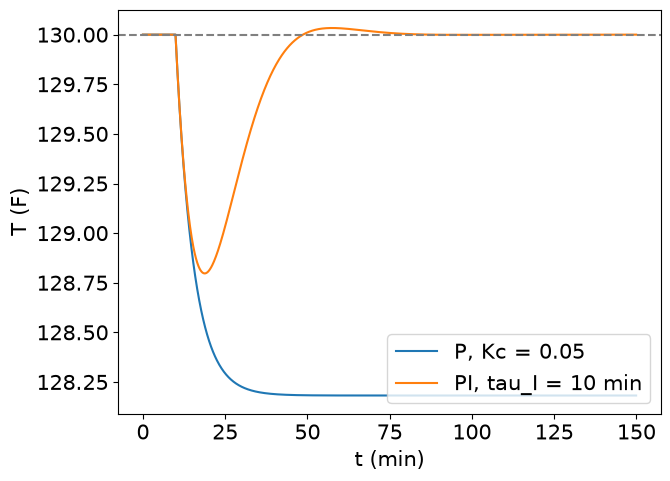

In [10]:
t = np.arange(len(T_P)) * 0.1
fig, ax = plt.subplots(figsize=(7, 5.25))
ax.plot(t, T_P, label="P, Kc = 0.05")
ax.plot(t, T_PI, label="PI, tau_I = 10 min")
ax.axhline(130, ls="--", c="gray")
ax.set(xlabel="t (min)", ylabel="T (F)")
ax.legend(loc="lower right")
plt.show()

**Code walkthrough.** Both curves start at 130 F and dip when the colder feed arrives at
t = 10 min. P settles 1.82 F low and stays there. PI dips less deeply
at first, overshoots slightly above the P curve's level and climbs back
to 130 F -- the "price" the book mentions: integral action makes the
response more oscillatory. The dashed line is the set point.

### Your Turn (8 min)

1. By hand: the offset for $K_c = 0.2$ /F.
2. Read the code: what does `run(0.0)[-1]` return,
   to one decimal place? (Hint: $K_c = 0$ means no feedback.)

(1) e_ss = 10/(1 + 90*0.2) = 10/19 = 0.53 F.
(2) 120.1. With Kc = 0 the burner stays at 70/90 and the tank heads
for 50 + 70 = 120 F; after 140 min of the 150 it is at
120 + 10 e^(-140/30) = 120.09 F. That is the open-loop response: the
full 10 F drop, matching the formula with Kc = 0 (offset 10/1 = 10 F).

### Check -- poll

Doubling $K_c$ from 0.05 to 0.1 changes the offset from 1.82 F to:

**A)** 0.91 F (halved)   **B)** 1.00 F   **C)** 0 F

B. Offset = 10/(1 + 90 Kc): 10/10 = 1.00 F. Not halved, because the
"1 +" in the denominator. Students who answer A are using offset
proportional to 1/Kc.

## Part C
### Apparent Error and a First Look at Instability

(Coughanowr & LeBlanc, Ch. 1, Some Further Complications)
<!-- source: coughanowr-ch1 -->

### Introduce -- the controller sees a lagged measurement

- A thermocouple does not jump to the water temperature; it **lags**.
- The controller acts on the **apparent error** $T_{set} - T_m$,
  not the true error.
- Book's warning: raise the gain far enough and the temperature
  oscillates with **increasing** amplitude -- until the heater's
  physical limits are reached.

### Derive 1/2 -- the sensor as a lag

Heat flows into the thermocouple at a rate set by $T - T_m$ (Ch. 4 makes this exact):

$$\tau_m\,\frac{dT_m}{dt} = T - T_m$$

Burner heat also arrives with a lag: $\tau_h\,dQ_h/dt = q - Q_h$.
Illustrative values: $\tau_m = 2$ min, $\tau_h = 3$ min.

### Derive 2/2 -- apparent versus true error

Subtract the two errors:

$$\underbrace{(T_{set} - T_m)}_{\text{apparent}} -
\underbrace{(T_{set} - T)}_{\text{true}} = T - T_m
= \tau_m\,\frac{dT_m}{dt}$$

While $T$ is changing the controller is always acting on old news.

### Code 1/2 -- the loop with two extra lags

- Three states now: heat input $Q_h$, water $T$, sensor $T_m$
- Each line is one lag equation from Derive 1/2
- The controller reads `Tm`, not `T`

In [11]:
def lagged_loop(Kc, t_end=150.0, dt=0.05):
    T = Tm = 130.0; Qh = 70/90; out = []
    for k in range(int(t_end / dt)):
        Ti = 60.0 if k * dt < 10 else 50.0
        q = np.clip(70/90 + Kc * (130.0 - Tm), 0, 1)
        Qh += dt * (q - Qh) / 3.0           # burner lag
        T += dt * dTdt(T, Ti, Qh)           # tank
        Tm += dt * (T - Tm) / 2.0           # sensor lag
        out.append(T)
    return np.array(out)

**Code walkthrough.** The structure is Part B's `run`, with two extra state variables. The
controller uses Tm (line 5): it acts on the apparent error. Line 6 is
the burner lag tau_h dQh/dt = q - Qh with tau_h = 3 min; line 7 the tank,
driven by the lagged heat Qh; line 8 the sensor lag with tau_m = 2 min.
The order matters only slightly for small dt. `T = Tm = 130.0` sets both
to 130 in one statement. Nothing is printed: the next cell uses it.

### Code 2/2 -- raise the gain

- Run three gains; compare the swing early and late
- `np.ptp` = peak-to-peak (max minus min)
- Growing swing means unstable; shrinking means stable

In [ ]:
for Kc in [0.05, 0.25, 0.4]:
    T = lagged_loop(Kc)
    n = len(T)
    mid, late = np.ptp(T[n//3:2*n//3]), np.ptp(T[2*n//3:])
    print(f"Kc = {Kc}: swing {mid:.2f} F -> {late:.2f} F")

**Code walkthrough.** For each gain the loop is simulated and split into thirds. The swing in
the middle third is compared with the swing in the last third. Expected:
Kc = 0.05: 0.01 -> 0.00 F (settled, with the 1.82 F offset of Part B);
Kc = 0.25: 0.45 -> 0.14 F (oscillates, but decaying: stable);
Kc = 0.4: 1.24 -> 1.24 F (a sustained cycle). At 0.4 the oscillation
grew until the burner hit 0 and 1 -- the clip -- exactly the book's
"until the physical limitations of the heating system are reached".
Predict before running: most expect higher gain to be better.

### Plot -- stable, oscillatory, unstable

- Same loop, three gains, one figure

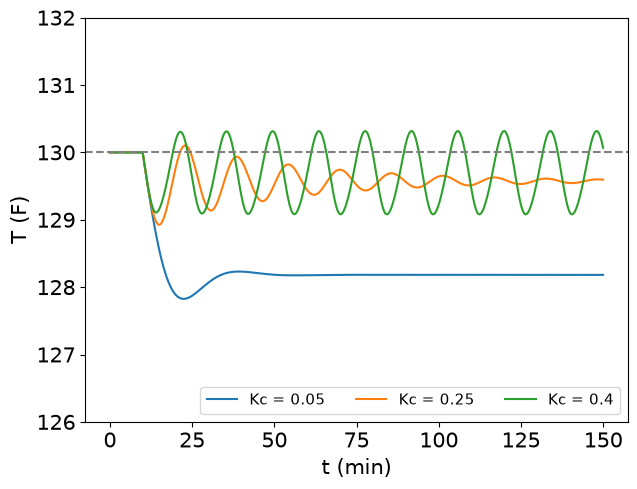

In [13]:
t = np.arange(len(lagged_loop(0.05))) * 0.05
fig, ax = plt.subplots(figsize=(7, 5.25))
for Kc in [0.05, 0.25, 0.4]:
    ax.plot(t, lagged_loop(Kc), label=f"Kc = {Kc}")
ax.axhline(130, ls="--", c="gray")
ax.set(xlabel="t (min)", ylabel="T (F)", ylim=(126, 132))
ax.legend(loc="lower right", ncol=3, fontsize=11)
plt.show()

**Code walkthrough.** One curve per gain. Kc = 0.05: smooth, offset 1.82 F. Kc = 0.25: a
smaller offset but a damped oscillation. Kc = 0.4: the cycle never dies;
without the burner limits it would grow without bound. The boundary lies
between: for these three lags it is Kc = 0.326 /F, which Lecture 6
computes in one line with the Routh test. The point of Ch. 1: gain cannot
simply be raised to kill offset.

### Your Turn (6 min)

1. By hand: at some instant $T = 128.0$ F and $T_m = 129.0$ F.
   What are the true and apparent errors?
2. Read the code: the burner is at its limit when `q` is 0 or 1.
   Which gain in Code 2/2 spends time at the limits, and why does
   that matter for the swing you saw?

(1) True error 130 - 128 = 2.0 F; apparent 130 - 129 = 1.0 F. The
controller under-reacts by half because the sensor has not caught up.
(2) Kc = 0.4 (about 30% of the time at a limit). Clipping caps the
amplitude, which is why the swing is constant at 1.24 F rather than
growing: a limit cycle. Without the clip the swing would keep growing.

### Check -- think-pair-share

The book says some systems become unstable with **any** amount of
integral action. Using Part B and Part C, explain why integral action
might make things *worse* when there is measurement lag.

Integral action keeps pushing as long as the (apparent) error persists;
with lag the error the controller sees is old, so the integral keeps
accumulating after the true temperature has already recovered, and the
loop overshoots. More phase lag, same direction as Part C's high gain.
Formalized with stability analysis in Lecture 6 and frequency response
in Lectures 7-8.

## Part D
### Narrow the Variance, Shift the Target; DCS Blocks

(Cecil Smith, Introduction and Sec. 1.1-1.2)
<!-- source: cecil-intro-1.1-1.2 -->

### Introduce -- why plants pay for better control (Cecil, Intro)

- Performance = **variance of the control error** (SP $-$ PV).
- Incentive: run closer to a limiting condition.
- Cecil: **"narrow the variance, shift the target."**
- Two routes: replace the PID (usually MPC), or keep the PID and add
  logic with DCS function blocks.

### Derive 1/2 -- where to put the target

A quality variable $y$ has an upper limit $L$ and scatter $\sigma$. Keep violations rare by staying $z$ standard deviations away:

$$y_{target} = L - z\,\sigma \qquad (z = 2:\ \text{about 2.3\% above } L)$$

### Derive 2/2 -- the payoff of narrowing

Halve the scatter, $\sigma_1 \to \sigma_2$, keep the same violation rate:

$$\Delta y_{target} = z\,(\sigma_1 - \sigma_2)$$

Every unit of $\Delta y$ is product or energy you were giving away.

### Code 1/2 -- operating data before and after

- Simulate 10,000 samples of $y$ for $\sigma = 1.0$ and $0.5$
- Targets from Derive 1/2 with $L = 100$, $z = 2$ (illustrative)
- Fraction of samples above $L$ should be about 2.3% for both

In [14]:
rng = np.random.default_rng(0)        # reproducible noise
L, z = 100.0, 2.0
for sigma in [1.0, 0.5]:
    target = L - z * sigma            # Derive 1/2
    y = target + sigma * rng.standard_normal(10_000)
    print(f"sigma {sigma}: target {target}, "
          f"above L {np.mean(y > L):.1%}")

sigma 1.0: target 98.0, above L 2.2%
sigma 0.5: target 99.0, above L 2.2%


**Code walkthrough.** `np.random.default_rng(0)` creates a random-number generator with a
fixed seed so the numbers repeat every run. For each sigma the target
is placed z sigma below the limit, and 10,000 normally distributed
samples are generated around it. `np.mean(y > L)` is the fraction of
True values, i.e. the violation rate. Expected: targets 98.0 and 99.0,
violation rates both close to 2.3% (sampling noise moves the second
decimal). Same risk, target 1.0 unit closer to the limit: Derive 2/2
with z(1.0 - 0.5) = 1.0.

### Code 2/2 -- the picture behind Cecil's phrase

- Two histograms, same limit, same violation rate

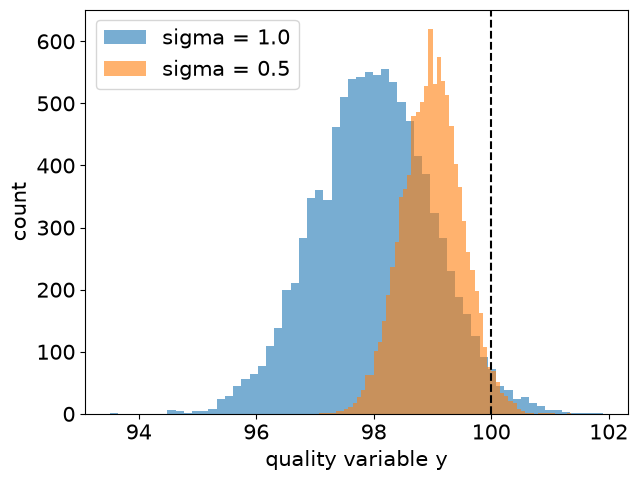

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.25))
for sigma in [1.0, 0.5]:
    y = (L - z*sigma) + sigma * rng.standard_normal(10_000)
    ax.hist(y, bins=60, alpha=0.6, label=f"sigma = {sigma}")
ax.axvline(L, c="k", ls="--")
ax.set(xlabel="quality variable y", ylabel="count")
ax.legend(loc="upper left")
plt.show()

**Code walkthrough.** `ax.hist` draws a histogram with 60 bins; `alpha=0.6` makes the two
overlapping histograms see-through. Both tails cross the dashed limit by
the same small amount. The narrow distribution sits 1.0 unit closer to
the limit: "narrow the variance" (thinner histogram), "shift the target"
(moved right). This is the economic argument behind every advanced
strategy in Cecil's book.

### Introduce -- blocks, tags and finite resolution (Sec. 1.1-1.2)

- Input, output (valve) and control blocks; output named
  **`<Tag>.<Attribute>`**, e.g. `TC4011.SP`.
- Summer: $Y = k_0 + k_1X_1 + k_2X_2$. Moving average:
  $Y_k = \frac{1}{N}\sum_{j=0}^{N-1} X_{k-j}$.
- Temperatures are stored to **0.1 F** resolution.
- Windup: *"occurs when changes in the controller output have no
  effect on the process variable."*

![](https://haiderejaz6.github.io/ProcessControl/lectures/01-intro-fundamentals/images/fig1-1_cascade_pid.jpeg)

### Code -- DCS blocks are one-line functions

- Summer and moving average, as Cecil writes them
- `np.round(x, 1)` imitates the 0.1 F input resolution

In [16]:
def summer(X1, X2, k0=0.0, k1=1.0, k2=1.0):
    return k0 + k1 * X1 + k2 * X2

def moving_average(x, N):
    return np.convolve(x, np.ones(N) / N, mode="valid")

print(summer(120.0, 10.0, k2=-1.0))     # subtraction
print(np.round([107.43, 107.46], 1))    # 0.1 F resolution

110.0
[107.4 107.5]


**Code walkthrough.** `summer` is Cecil's summer equation with default coefficients; passing
k2=-1.0 turns it into a subtractor, which is why Cecil says the summer
"also provides subtraction". Prints 110.0. `moving_average` uses
`np.convolve` with N equal weights 1/N: each output is the average of
the last N inputs, Cecil's moving-average equation. `mode="valid"` keeps
only full windows. The last line prints [107.4 107.5]: two readings
0.03 F apart can land on different 0.1 F steps.

### Build on it -- resolution, and the cost of smoothing

- A slow 0.02 F/min ramp, measured at 0.1 F resolution
- Smoothing removes the staircase but adds **lag**
- For a ramp, an average over $T_A$ trails by $T_A/2$

In [17]:
t = np.arange(0, 60, 0.5)                  # min, sample 0.5 min
T_true = 107.0 + 0.02 * t                  # slow ramp
T_meas = np.round(T_true, 1)               # 0.1 F resolution
T_avg = moving_average(T_meas, 20)         # T_A = 10 min
lag = T_true[19:] - T_avg                  # true minus smoothed
print(f"steps in raw signal: {np.sum(np.diff(T_meas) != 0)}")
print(f"average lag of smoothed signal: {lag.mean():.3f} F")

steps in raw signal: 12
average lag of smoothed signal: 0.095 F


**Code walkthrough.** The true temperature rises 0.02 F per minute; sampled every 0.5 min it
changes 0.01 F per sample, but the stored value moves only in 0.1 F
steps (`np.round(..., 1)`). The raw signal therefore changes only 12
times in 60 min: a staircase. A 20-sample moving average (T_A = 10 min)
smooths it, but `lag` shows the price: the smoothed value trails the
true one by about 0.10 F. On a 0.02 F/min ramp that is about 5 min,
i.e. T_A/2: an average of the last 10 minutes describes the process as
it was 5 minutes ago. Cecil's warning: filtering "adds undesirable lag
to a control loop" -- and Part C showed what lag does to a loop.

### Build on it -- windup, as a logic statement

- Cecil's level-to-flow cascade: valve fully open gives 70 gpm
- Windup condition: output changes no longer move the PV
- Logic statements become Python booleans

In [18]:
def flow_from_valve(opening_pct, max_flow=70.0):
    return max_flow * min(opening_pct, 100.0) / 100.0

FC_SP = 85.0                              # set by the level ctrl
FC_MN = 100.0                             # flow ctrl output, %
FC_QH = FC_MN >= 100.0                    # at upper output limit
LC_TRKMR = FC_QH                          # Cecil: LC.TRKMR = FC.QH
print(flow_from_valve(FC_MN), "gpm; windup risk:", LC_TRKMR)

70.0 gpm; windup risk: True


**Code walkthrough.** `flow_from_valve` caps the flow: beyond 100% opening nothing changes,
and 100% gives only 70 gpm. The level controller asks for 85 gpm
(FC_SP), so the flow controller drives its output to 100% and sits there.
FC_QH ("output at its upper limit") is a Python boolean: True. Cecil's
logic statement LC.TRKMR = FC.QH becomes one assignment: integral
tracking in the level controller switches on. Prints "70.0 gpm; windup
risk: True". Without it, the level controller would keep integrating an
error it can no longer correct: reset windup.

### Your Turn (8 min)

1. By hand: a plant halves its scatter from $\sigma = 0.8$ to $0.4$
   with $z = 2$. How far can the target move?
2. Read the code: what does this print?

```python
print(summer(50.0, 20.0, k0=5.0, k1=0.5, k2=2.0))
print(flow_from_valve(60.0))
```

(1) Delta = 2(0.8 - 0.4) = 0.8 units toward the limit.
(2) 5 + 0.5*50 + 2*20 = 70.0; then 70 * 60/100 = 42.0 gpm.
Common slip in (2): using 60 as a flow instead of a percent opening.

### Check -- cold-call

A plant asks: "why use override control instead of just tuning the
PID harder?" Which of our two books answers that -- and why that one?

Cecil Smith: it is a question of plant structure and practice (limits,
windup, logic around the PID), not of deriving a model. Coughanowr
gives the theory of why tuning harder fails (Part C: instability);
Cecil gives the industrial fix (Ch. 4, Lecture 9).

### Wrap-up

**Derived, then coded:** the hot water tank under on/off, P and PI
control; offset $e_{ss} = \Delta d/(1 + KK_c)$; apparent error and the
gain limit; "narrow the variance, shift the target"; DCS blocks.

**Tools:** `def`, `for` loops (Euler steps), `sp.solve`, `sp.limit`,
`np.clip`, `np.random`, `np.convolve`

**Next:** Ch. 2-3 -- deriving the tank models we borrowed today, and
solving them with Laplace transforms.